In [1]:
# Colab setup
!pip install -q kagglehub segmentation-models-pytorch seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.0 MB/s eta 0:00:00


In [2]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision import models
import segmentation_models_pytorch as smp

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from IPython.display import display

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    torch.backends.cudnn.benchmark = True
print("Device:", device)


Device: cuda


In [3]:
import kagglehub

# Download BRISC 2025 dataset
path = kagglehub.dataset_download("briscdataset/brisc2025")
print("kagglehub returned:", path)

# Robustly find the folder that contains classification_task and segmentation_task.
def find_brisc_root(download_path):
    download_path = Path(download_path)
    candidates = [download_path, download_path / "brisc2025"]
    candidates += [p for p in download_path.rglob("brisc2025") if p.is_dir()]
    candidates += [p for p in download_path.rglob("*") if p.is_dir()]

    seen = set()
    for p in candidates:
        if p in seen:
            continue
        seen.add(p)
        if (p / "classification_task").is_dir() and (p / "segmentation_task").is_dir():
            return p
    raise FileNotFoundError(
        "Could not find dataset root containing classification_task and segmentation_task. "
        "Print the directory tree below and check the Kaggle dataset path."
    )

base_dataset_path = find_brisc_root(path)
classification_task_path = base_dataset_path / "classification_task"
segmentation_task_path = base_dataset_path / "segmentation_task"
classification_train_path = classification_task_path / "train"
classification_test_path = classification_task_path / "test"

print("Base dataset path:", base_dataset_path)
print("Classification train:", classification_train_path, classification_train_path.exists())
print("Classification test :", classification_test_path, classification_test_path.exists())
print("Segmentation task   :", segmentation_task_path, segmentation_task_path.exists())
print("Train class folders :", sorted([p.name for p in classification_train_path.iterdir() if p.is_dir()]))
print("Test class folders  :", sorted([p.name for p in classification_test_path.iterdir() if p.is_dir()]))


100%|██████████| 250M/250M [00:02<00:00, 128MB/s]

Extracting files...


kagglehub returned: /root/.cache/kagglehub/datasets/briscdataset/brisc2025/versions/6
Base dataset path: /root/.cache/kagglehub/datasets/briscdataset/brisc2025/versions/6/brisc2025
Classification train: /root/.cache/kagglehub/datasets/briscdataset/brisc2025/versions/6/brisc2025/classification_task/train True
Classification test : /root/.cache/kagglehub/datasets/briscdataset/brisc2025/versions/6/brisc2025/classification_task/test True
Segmentation task   : /root/.cache/kagglehub/datasets/briscdataset/brisc2025/versions/6/brisc2025/segmentation_task True
Train class folders : ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Test class folders  : ['glioma', 'meningioma', 'no_tumor', 'pituitary']


## Build dataframes correctly

The important fix is that only `classification_task/train` is split into train/validation. The official test folder is kept completely separate until final evaluation.

In [4]:
CLASS_NAMES = ["glioma", "meningioma", "no_tumor", "pituitary"]
class_to_idx = {name: i for i, name in enumerate(CLASS_NAMES)}
idx_to_class = {i: name for name, i in class_to_idx.items()}
IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

# Some BRISC filenames contain class codes. This fallback helps if folders or masks use code names.
CODE_TO_CLASS = {"gl": "glioma", "me": "meningioma", "no": "no_tumor", "pi": "pituitary"}


def image_id_from_path(path):
    return Path(path).stem


def build_mask_lookup(segmentation_root):
    """Map image stem to mask path from segmentation_task/train and segmentation_task/test.

    This does not use segmentation test images for training. It only lets us find a mask for an
    image that also exists in classification_task/train or classification_task/test.
    """
    lookup = {}
    segmentation_root = Path(segmentation_root)

    for split in ["train", "test"]:
        images_dir = segmentation_root / split / "images"
        masks_dir = segmentation_root / split / "masks"
        if not images_dir.is_dir() or not masks_dir.is_dir():
            continue

        # Prefer masks matched through image filenames, because masks may be png while images are jpg.
        for img_path in images_dir.iterdir():
            if img_path.suffix.lower() not in IMG_EXTS:
                continue
            stem = img_path.stem
            possible_masks = [masks_dir / f"{stem}{ext}" for ext in IMG_EXTS]
            for mask_path in possible_masks:
                if mask_path.exists():
                    lookup[stem] = str(mask_path)
                    break

        # Also add any mask files directly by stem.
        for mask_path in masks_dir.iterdir():
            if mask_path.suffix.lower() in IMG_EXTS:
                lookup.setdefault(mask_path.stem, str(mask_path))

    return lookup


mask_lookup = build_mask_lookup(segmentation_task_path)
print("Masks found:", len(mask_lookup))


def build_classification_df(split_root, split_name, mask_lookup):
    rows = []
    split_root = Path(split_root)
    if not split_root.is_dir():
        raise FileNotFoundError(f"Missing classification split folder: {split_root}")

    for label in CLASS_NAMES:
        class_dir = split_root / label
        if not class_dir.is_dir():
            print(f"Warning: missing class folder: {class_dir}")
            continue

        for image_path in sorted(class_dir.iterdir()):
            if image_path.suffix.lower() not in IMG_EXTS:
                continue

            stem = image_path.stem
            mask_path = None if label == "no_tumor" else mask_lookup.get(stem)
            rows.append({
                "image_id": stem,
                "image_path": str(image_path),
                "label": label,
                "label_encoded": class_to_idx[label],
                "mask_path": mask_path,
                "split": split_name,
                "has_real_mask": mask_path is not None,
            })

    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError(f"No images found in {split_root}")
    return df


full_train_df = build_classification_df(classification_train_path, "official_train", mask_lookup)
test_df = build_classification_df(classification_test_path, "official_test", mask_lookup)

print("Official train samples:", len(full_train_df))
print("Official test samples :", len(test_df))
print("\nOfficial train class distribution:")
display(full_train_df["label"].value_counts().reindex(CLASS_NAMES, fill_value=0))
print("\nOfficial test class distribution:")
display(test_df["label"].value_counts().reindex(CLASS_NAMES, fill_value=0))
print("\nReal masks in official train:", int(full_train_df["has_real_mask"].sum()))
print("Real masks in official test :", int(test_df["has_real_mask"].sum()))
print("Blank masks will be used for no_tumor and any image without a real mask.")


Masks found: 4793
Official train samples: 5000
Official test samples : 1000

Official train class distribution:


,count
label,
glioma,1147
meningioma,1329
no_tumor,1067
pituitary,1457



Official test class distribution:


,count
label,
glioma,254
meningioma,306
no_tumor,140
pituitary,300



Real masks in official train: 3933
Real masks in official test : 860
Blank masks will be used for no_tumor and any image without a real mask.


In [5]:
# Split only official training data. Do not touch official test data here.
train_df, val_df = train_test_split(
    full_train_df,
    test_size=0.20,
    stratify=full_train_df["label_encoded"],
    random_state=SEED,
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df), "Validation:", len(val_df), "Official test:", len(test_df))

print("\nTrain distribution:")
display(train_df["label"].value_counts().reindex(CLASS_NAMES, fill_value=0))
print("\nValidation distribution:")
display(val_df["label"].value_counts().reindex(CLASS_NAMES, fill_value=0))
print("\nOfficial test distribution:")
display(test_df["label"].value_counts().reindex(CLASS_NAMES, fill_value=0))


Train: 4000 Validation: 1000 Official test: 1000

Train distribution:


,count
label,
glioma,918
meningioma,1063
no_tumor,854
pituitary,1165



Validation distribution:


,count
label,
glioma,229
meningioma,266
no_tumor,213
pituitary,292



Official test distribution:


,count
label,
glioma,254
meningioma,306
no_tumor,140
pituitary,300


## Dataset and mask preprocessing

Masks are resized using nearest-neighbor interpolation and then thresholded to binary values. This prevents blurred/soft mask labels.

In [6]:
IMG_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 2

image_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE), interpolation=T.InterpolationMode.BILINEAR),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

mask_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE), interpolation=T.InterpolationMode.NEAREST),
    T.ToTensor(),
])


class BrainMultiTaskDataset(Dataset):
    def __init__(self, dataframe, image_transform=None, mask_transform=None, img_size=224):
        self.df = dataframe.reset_index(drop=True)
        self.image_transform = image_transform
        self.mask_transform = mask_transform
        self.img_size = img_size

    def __len__(self):
        return len(self.df)

    def _blank_mask(self, image_size=None):
        if image_size is None:
            image_size = (self.img_size, self.img_size)
        return Image.fromarray(np.zeros((image_size[1], image_size[0]), dtype=np.uint8), mode="L")

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")

        mask_path = row["mask_path"]
        if isinstance(mask_path, str) and os.path.exists(mask_path):
            mask = Image.open(mask_path).convert("L")
        else:
            # Blank mask for no_tumor and for classification images without segmentation annotation.
            mask = self._blank_mask(image.size)

        if self.image_transform is not None:
            image = self.image_transform(image)
        if self.mask_transform is not None:
            mask = self.mask_transform(mask)

        # Force binary mask after nearest-neighbor resize.
        mask = (mask > 0.5).float()
        label = torch.tensor(int(row["label_encoded"]), dtype=torch.long)
        return image, mask, label


train_ds = BrainMultiTaskDataset(train_df, image_transform, mask_transform, IMG_SIZE)
val_ds = BrainMultiTaskDataset(val_df, image_transform, mask_transform, IMG_SIZE)
test_ds = BrainMultiTaskDataset(test_df, image_transform, mask_transform, IMG_SIZE)

pin_memory = device.type == "cuda"
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=pin_memory)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin_memory)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin_memory)

print("Batches -> train:", len(train_loader), "val:", len(val_loader), "test:", len(test_loader))


Batches -> train: 250 val: 63 test: 63


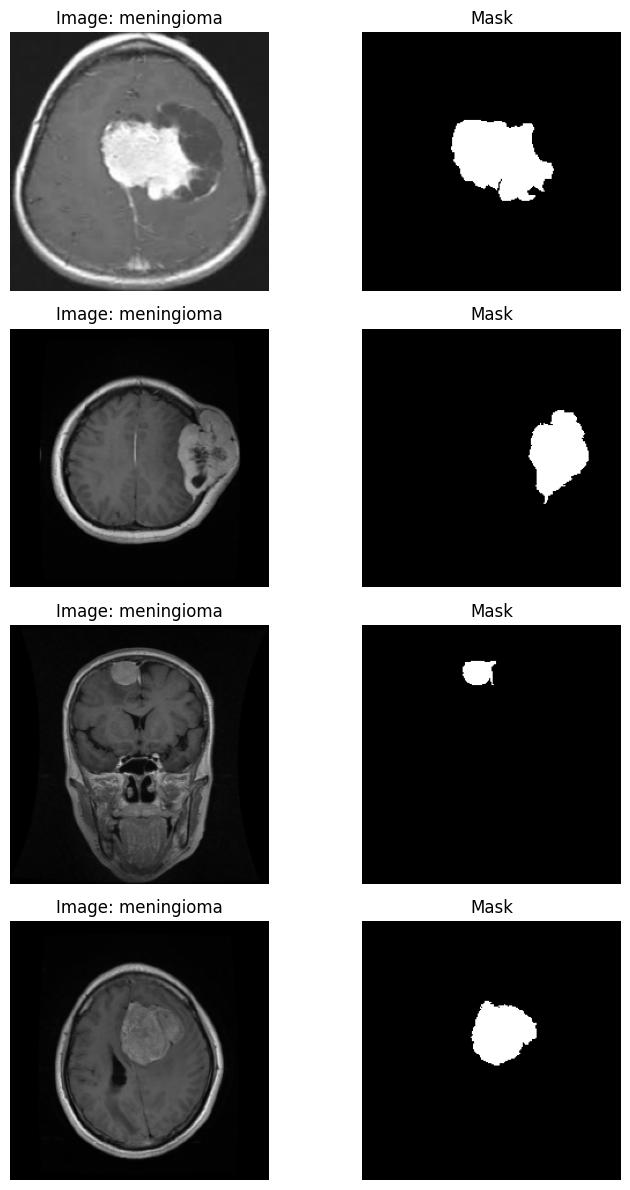

In [7]:
def denormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (img_tensor.cpu() * std + mean).clamp(0, 1)


def show_samples(dataset, n=4):
    n = min(n, len(dataset))
    plt.figure(figsize=(8, 3 * n))
    for i in range(n):
        image, mask, label = dataset[i]
        plt.subplot(n, 2, 2 * i + 1)
        plt.imshow(denormalize(image).permute(1, 2, 0))
        plt.title(f"Image: {idx_to_class[int(label)]}")
        plt.axis("off")

        plt.subplot(n, 2, 2 * i + 2)
        plt.imshow(mask.squeeze(), cmap="gray")
        plt.title("Mask")
        plt.axis("off")
    plt.tight_layout()
    plt.show()


show_samples(train_ds, n=4)


## Model

This keeps the original multitask idea: one classification output and one segmentation output.

In [8]:
class MultiTaskModel(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        # Classification branch backbone
        try:
            weights = models.ResNet50_Weights.IMAGENET1K_V2
            backbone_model = models.resnet50(weights=weights)
        except Exception:
            # Fallback for older torchvision versions
            backbone_model = models.resnet50(pretrained=True)

        self.backbone = nn.Sequential(*list(backbone_model.children())[:-2])
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(2048, num_classes)

        # Segmentation branch
        self.seg_head = smp.DeepLabV3Plus(
            encoder_name="resnet50",
            encoder_weights="imagenet",
            in_channels=3,
            classes=1,
        )

    def forward(self, x):
        features = self.backbone(x)
        cls_logits = self.fc(torch.flatten(self.pool(features), 1))
        seg_logits = self.seg_head(x)
        return cls_logits, seg_logits


model = MultiTaskModel(num_classes=len(CLASS_NAMES)).to(device)
criterion_cls = nn.CrossEntropyLoss()
criterion_seg = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))
print("Model ready.")


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 160MB/s]


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Model ready.


/tmp/ipykernel_9224/1039502914.py:36: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))


In [9]:
def batch_accuracy(cls_logits, labels):
    preds = torch.argmax(cls_logits, dim=1)
    return (preds == labels).float().mean().item()


def batch_iou(seg_logits, masks, eps=1e-6):
    preds = (torch.sigmoid(seg_logits) > 0.5).float()
    intersection = (preds * masks).sum(dim=(1, 2, 3))
    union = ((preds + masks) > 0).float().sum(dim=(1, 2, 3))
    return ((intersection + eps) / (union + eps)).mean().item()


def run_epoch(model, loader, training=False):
    model.train() if training else model.eval()
    total_loss, total_acc, total_iou = 0.0, 0.0, 0.0

    context = torch.enable_grad() if training else torch.no_grad()
    with context:
        for images, masks, labels in tqdm(loader, leave=False):
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            if training:
                optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
                cls_logits, seg_logits = model(images)
                loss_cls = criterion_cls(cls_logits, labels)
                loss_seg = criterion_seg(seg_logits, masks)
                loss = loss_cls + loss_seg

            if training:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            total_loss += float(loss.item())
            total_acc += batch_accuracy(cls_logits.detach(), labels)
            total_iou += batch_iou(seg_logits.detach(), masks)

    n = max(1, len(loader))
    return total_loss / n, total_acc / n, total_iou / n


In [10]:
EPOCHS = 5

history = {
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": [],
    "train_iou": [], "val_iou": [],
}

best_val_loss = float("inf")
best_model_path = "best_corrected_brain_multitask.pth"

for epoch in range(EPOCHS):
    train_loss, train_acc, train_iou = run_epoch(model, train_loader, training=True)
    val_loss, val_acc, val_iou = run_epoch(model, val_loader, training=False)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["train_iou"].append(train_iou)
    history["val_iou"].append(val_iou)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)

    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print(f"  Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | IoU: {train_iou:.4f}")
    print(f"  Val   Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | IoU: {val_iou:.4f}")

print("Best model saved to:", best_model_path)


  0%|          | 0/250 [00:00<?, ?it/s]

/tmp/ipykernel_9224/1836475308.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(np.zeros((image_size[1], image_size[0]), dtype=np.uint8), mode="L")
/tmp/ipykernel_9224/1836475308.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(np.zeros((image_size[1], image_size[0]), dtype=np.uint8), mode="L")
/tmp/ipykernel_9224/1836475308.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(np.zeros((image_size[1], image_size[0]), dtype=np.uint8), mode="L")
/tmp/ipykernel_9224/1836475308.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(np.zeros((image_size[1], image_size[0]), dtype=np.uint8), mode="L")
/tmp/ipykernel_9224/4075614628.py:27: FutureWarning: `torch.cuda.amp.autocast(args...)` 

  0%|          | 0/63 [00:00<?, ?it/s]

/tmp/ipykernel_9224/1836475308.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(np.zeros((image_size[1], image_size[0]), dtype=np.uint8), mode="L")
/tmp/ipykernel_9224/1836475308.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(np.zeros((image_size[1], image_size[0]), dtype=np.uint8), mode="L")
/tmp/ipykernel_9224/1836475308.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(np.zeros((image_size[1], image_size[0]), dtype=np.uint8), mode="L")
/tmp/ipykernel_9224/1836475308.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(np.zeros((image_size[1], image_size[0]), dtype=np.uint8), mode="L")


Epoch 1/5
  Train Loss: 0.5805 | Acc: 0.8788 | IoU: 0.2355
  Val   Loss: 0.2112 | Acc: 0.9623 | IoU: 0.5226


...

  0%|          | 0/250 [00:00<?, ?it/s]

/tmp/ipykernel_9224/1836475308.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(np.zeros((image_size[1], image_size[0]), dtype=np.uint8), mode="L")
/tmp/ipykernel_9224/1836475308.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(np.zeros((image_size[1], image_size[0]), dtype=np.uint8), mode="L")
/tmp/ipykernel_9224/1836475308.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(np.zeros((image_size[1], image_size[0]), dtype=np.uint8), mode="L")
/tmp/ipykernel_9224/1836475308.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(np.zeros((image_size[1], image_size[0]), dtype=np.uint8), mode="L")


  0%|          | 0/63 [00:00<?, ?it/s]

/tmp/ipykernel_9224/1836475308.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(np.zeros((image_size[1], image_size[0]), dtype=np.uint8), mode="L")
/tmp/ipykernel_9224/1836475308.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(np.zeros((image_size[1], image_size[0]), dtype=np.uint8), mode="L")
/tmp/ipykernel_9224/1836475308.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(np.zeros((image_size[1], image_size[0]), dtype=np.uint8), mode="L")
/tmp/ipykernel_9224/1836475308.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(np.zeros((image_size[1], image_size[0]), dtype=np.uint8), mode="L")


Epoch 5/5
  Train Loss: 0.0419 | Acc: 0.9925 | IoU: 0.7464
  Val   Loss: 0.0739 | Acc: 0.9812 | IoU: 0.7308
Best model saved to: best_corrected_brain_multitask.pth


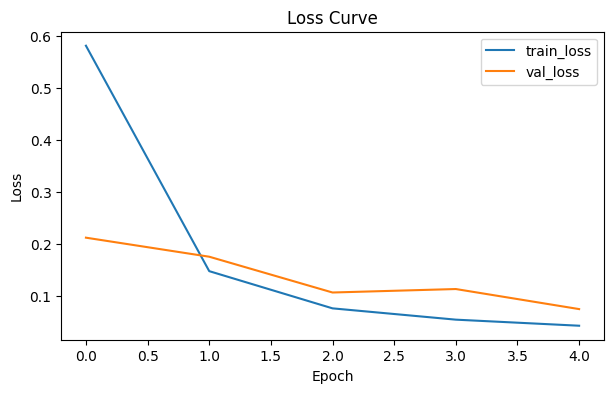

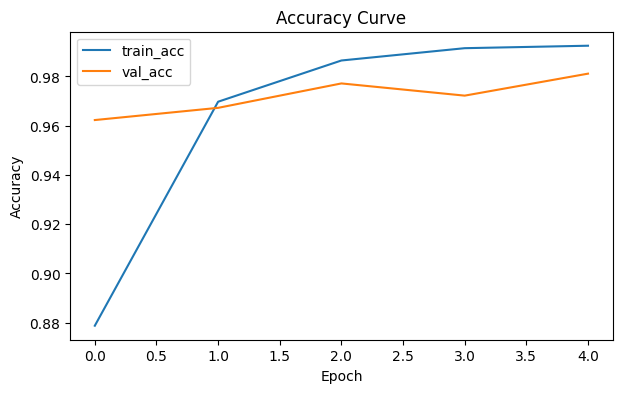

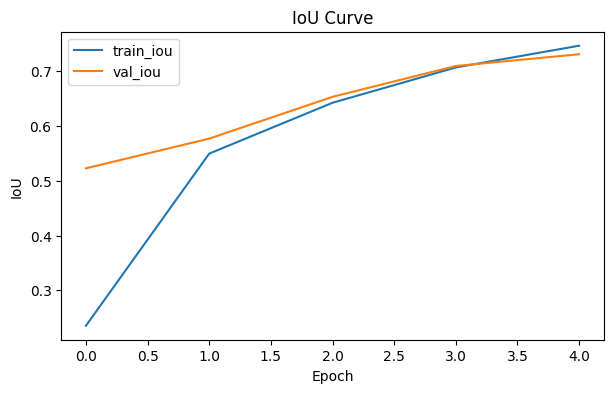

In [11]:
def plot_history(history):
    plots = [
        ("train_loss", "val_loss", "Loss Curve", "Loss"),
        ("train_acc", "val_acc", "Accuracy Curve", "Accuracy"),
        ("train_iou", "val_iou", "IoU Curve", "IoU"),
    ]
    for train_key, val_key, title, ylabel in plots:
        plt.figure(figsize=(7, 4))
        plt.plot(history[train_key], label=train_key)
        plt.plot(history[val_key], label=val_key)
        plt.title(title)
        plt.xlabel("Epoch")
        plt.ylabel(ylabel)
        plt.legend()
        plt.show()


plot_history(history)


## Final official test evaluation

This section evaluates only on `classification_task/test`, which was not used during training or validation.

In [12]:
# Load best validation checkpoint before final test evaluation.
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()


def collect_predictions(model, loader):
    y_true, y_pred = [], []
    test_loss, test_acc, test_iou = run_epoch(model, loader, training=False)

    with torch.no_grad():
        for images, masks, labels in tqdm(loader, leave=False):
            images = images.to(device, non_blocking=True)
            cls_logits, _ = model(images)
            preds = torch.argmax(cls_logits, dim=1).cpu().numpy()
            y_pred.extend(preds.tolist())
            y_true.extend(labels.numpy().tolist())

    return np.array(y_true), np.array(y_pred), test_loss, test_acc, test_iou


y_true, y_pred, test_loss, test_acc, test_iou = collect_predictions(model, test_loader)

print(f"Official Test Loss: {test_loss:.4f}")
print(f"Official Test Classification Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(f"Official Test Segmentation IoU: {test_iou:.4f}")


  0%|          | 0/63 [00:00<?, ?it/s]

/tmp/ipykernel_9224/4075614628.py:27: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
/tmp/ipykernel_9224/1836475308.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(np.zeros((image_size[1], image_size[0]), dtype=np.uint8), mode="L")
/tmp/ipykernel_9224/1836475308.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(np.zeros((image_size[1], image_size[0]), dtype=np.uint8), mode="L")


  0%|          | 0/63 [00:00<?, ?it/s]

/tmp/ipykernel_9224/1836475308.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(np.zeros((image_size[1], image_size[0]), dtype=np.uint8), mode="L")
/tmp/ipykernel_9224/1836475308.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(np.zeros((image_size[1], image_size[0]), dtype=np.uint8), mode="L")


Official Test Loss: 0.1055
Official Test Classification Accuracy: 0.9760
Official Test Segmentation IoU: 0.7175


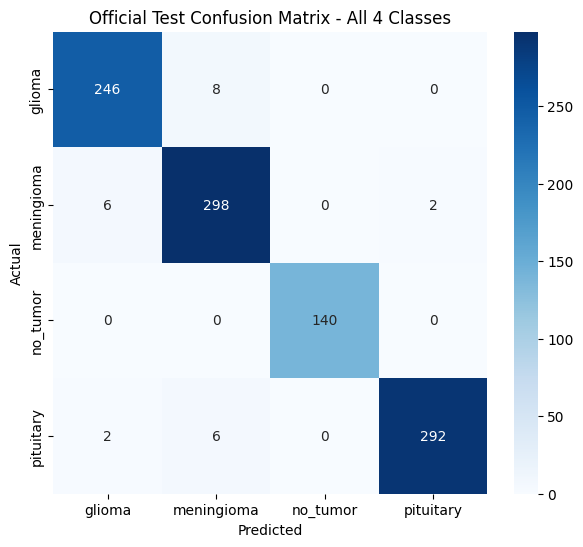

Classification Report - Official Test Set
              precision    recall  f1-score   support

      glioma     0.9685    0.9685    0.9685       254
  meningioma     0.9551    0.9739    0.9644       306
    no_tumor     1.0000    1.0000    1.0000       140
   pituitary     0.9932    0.9733    0.9832       300

    accuracy                         0.9760      1000
   macro avg     0.9792    0.9789    0.9790      1000
weighted avg     0.9762    0.9760    0.9761      1000



In [13]:
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(CLASS_NAMES))))

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Official Test Confusion Matrix - All 4 Classes")
plt.show()

print("Classification Report - Official Test Set")
print(classification_report(
    y_true,
    y_pred,
    labels=list(range(len(CLASS_NAMES))),
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0,
))


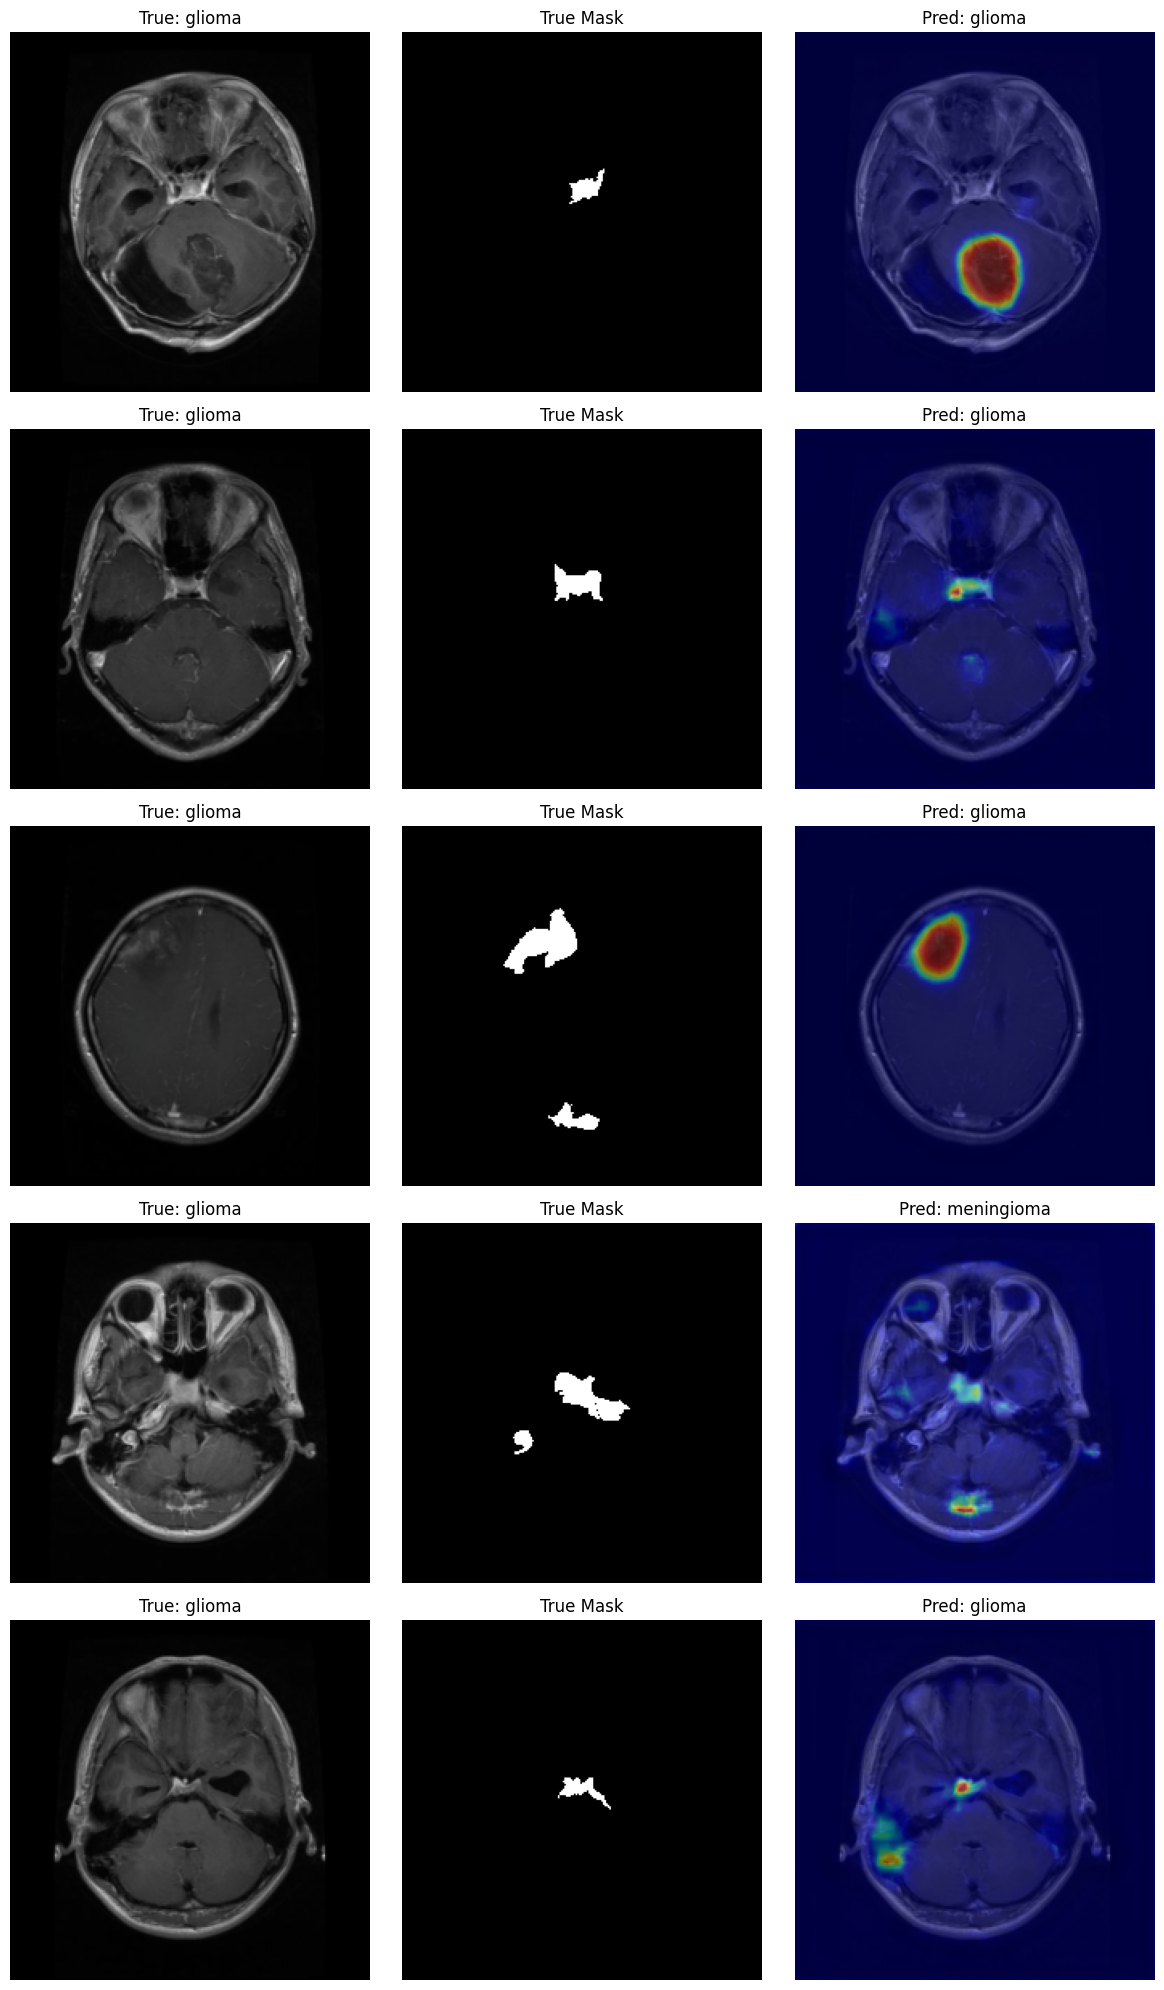

In [14]:
def visualize_predictions(model, dataset, n=5):
    model.eval()
    n = min(n, len(dataset))
    plt.figure(figsize=(12, 4 * n))

    for i in range(n):
        image, mask, label = dataset[i]
        with torch.no_grad():
            cls_logits, seg_logits = model(image.unsqueeze(0).to(device))

        pred_class = int(torch.argmax(cls_logits, dim=1).cpu().item())
        pred_mask = torch.sigmoid(seg_logits).cpu().squeeze().numpy()
        img_show = denormalize(image).permute(1, 2, 0)

        plt.subplot(n, 3, 3 * i + 1)
        plt.imshow(img_show)
        plt.title(f"True: {idx_to_class[int(label)]}")
        plt.axis("off")

        plt.subplot(n, 3, 3 * i + 2)
        plt.imshow(mask.squeeze(), cmap="gray")
        plt.title("True Mask")
        plt.axis("off")

        plt.subplot(n, 3, 3 * i + 3)
        plt.imshow(img_show)
        plt.imshow(pred_mask, cmap="jet", alpha=0.45)
        plt.title(f"Pred: {idx_to_class[pred_class]}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


visualize_predictions(model, test_ds, n=5)


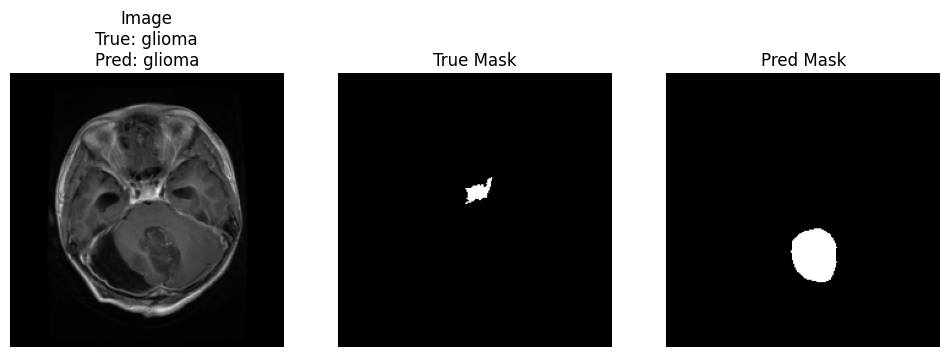

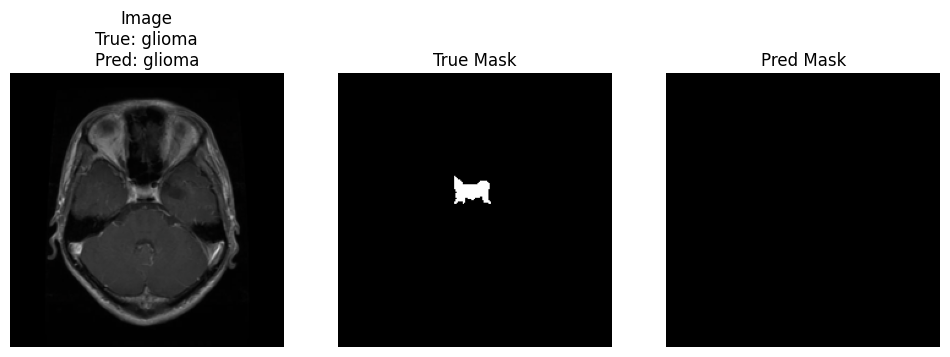

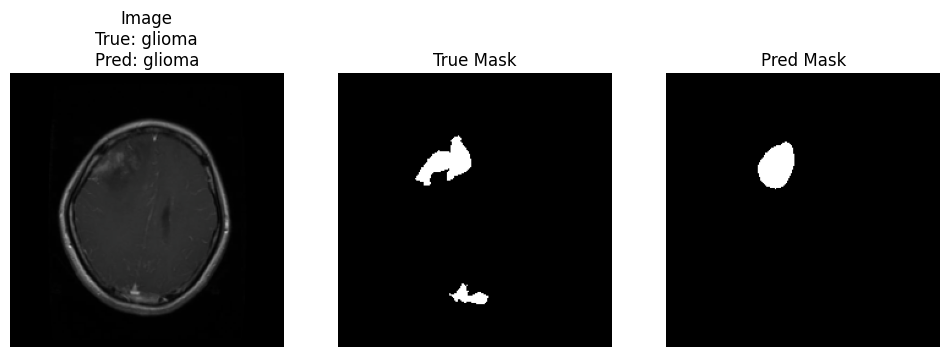

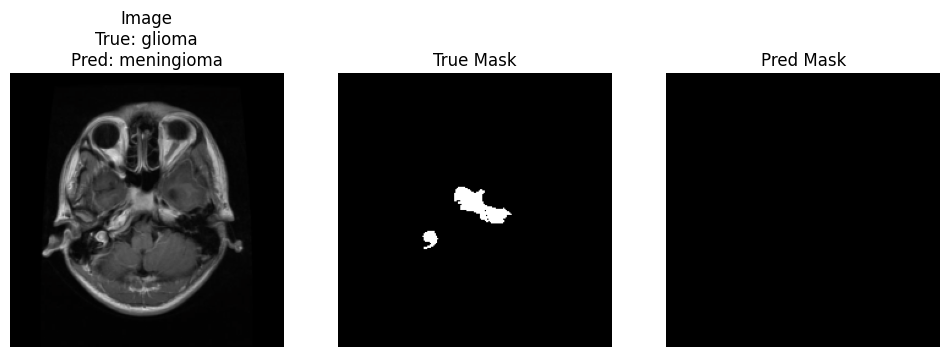

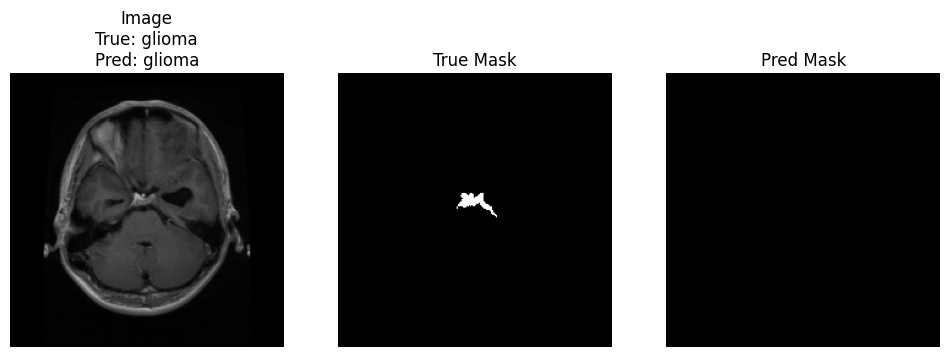

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import torch # Added torch import

# The 'device' and 'denormalize' function are defined in earlier cells and are needed here.
# The 'model', 'test_ds', and 'CLASS_NAMES' are also defined in earlier cells.

def show_predictions(model, dataset, class_names, num_samples=5):
    model.eval() # Set model to evaluation mode
    num_samples = min(num_samples, len(dataset)) # Ensure num_samples doesn't exceed dataset size

    for i in range(num_samples):
        # Get a single sample from the dataset.
        # dataset.getitem returns image (tensor), mask (tensor), label (tensor)
        image, true_mask_tensor, true_label_tensor = dataset[i]

        # Prepare image for model: add batch dimension and move to device
        image_input = image.unsqueeze(0).to(device)

        with torch.no_grad():
            # PyTorch model inference: returns classification logits and segmentation logits
            cls_logits, seg_logits = model(image_input)

        # Process classification predictions
        pred_label_idx = torch.argmax(cls_logits, dim=1).item()
        true_label_idx = true_label_tensor.item()

        # Process segmentation predictions
        # Apply sigmoid to get probabilities, squeeze to remove batch/channel dim, move to CPU, convert to numpy
        pred_mask_probs = torch.sigmoid(seg_logits).squeeze().cpu().numpy()
        pred_mask_bin = (pred_mask_probs > 0.5).astype(np.float32)

        # Prepare original image for display: denormalize and change channel order
        img_display = denormalize(image).permute(1, 2, 0).cpu().numpy()
        true_mask_display = true_mask_tensor.squeeze().cpu().numpy()

        plt.figure(figsize=(12,4))

        # Original Image
        plt.subplot(1,3,1)
        plt.imshow(img_display)
        plt.title(f"Image\nTrue: {class_names[true_label_idx]}\nPred: {class_names[pred_label_idx]}")
        plt.axis('off')

        # True Mask
        plt.subplot(1,3,2)
        plt.imshow(true_mask_display, cmap='gray')
        plt.title("True Mask")
        plt.axis('off')

        # Predicted Mask
        plt.subplot(1,3,3)
        plt.imshow(pred_mask_bin, cmap='gray')
        plt.title("Pred Mask")
        plt.axis('off')

        plt.show()

# Run it
# Changed 'test_dataset' to 'test_ds' and 'class_names' to 'CLASS_NAMES'
show_predictions(model, test_ds, CLASS_NAMES)

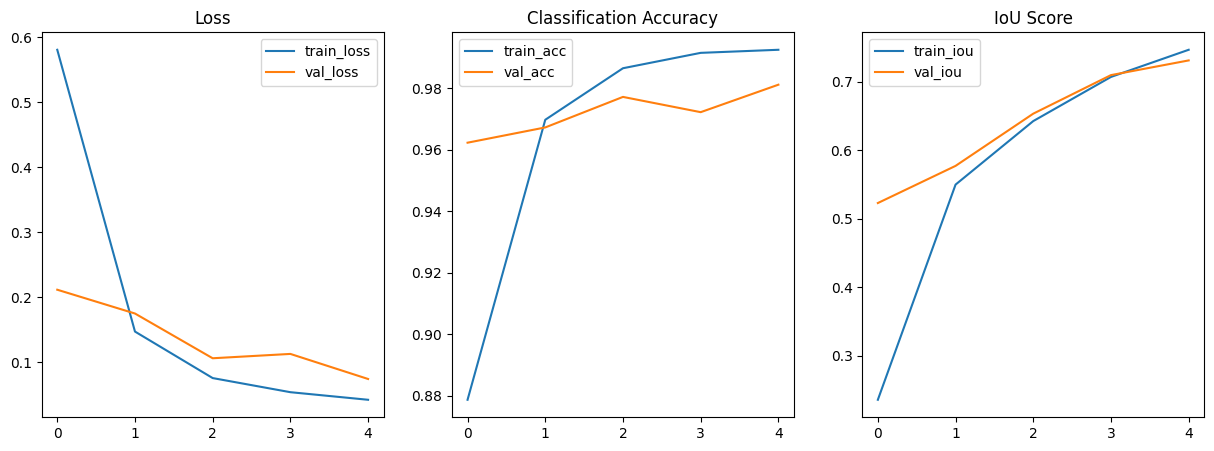

In [19]:
import matplotlib.pyplot as plt

history_dict = history

plt.figure(figsize=(15,5))

# Loss
plt.subplot(1,3,1)
plt.plot(history_dict['train_loss'], label='train_loss')
plt.plot(history_dict['val_loss'], label='val_loss')
plt.title("Loss")
plt.legend()

# Classification Accuracy
plt.subplot(1,3,2)
plt.plot(history_dict['train_acc'], label='train_acc')
plt.plot(history_dict['val_acc'], label='val_acc')
plt.title("Classification Accuracy")
plt.legend()

# Dice (or IoU if you used it)
if 'train_iou' in history_dict:
    plt.subplot(1,3,3)
    plt.plot(history_dict['train_iou'], label='train_iou')
    plt.plot(history_dict['val_iou'], label='val_iou')
    plt.title("IoU Score")
    plt.legend()

plt.show()

/tmp/ipykernel_9224/1836475308.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(np.zeros((image_size[1], image_size[0]), dtype=np.uint8), mode="L")
/tmp/ipykernel_9224/1836475308.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(np.zeros((image_size[1], image_size[0]), dtype=np.uint8), mode="L")


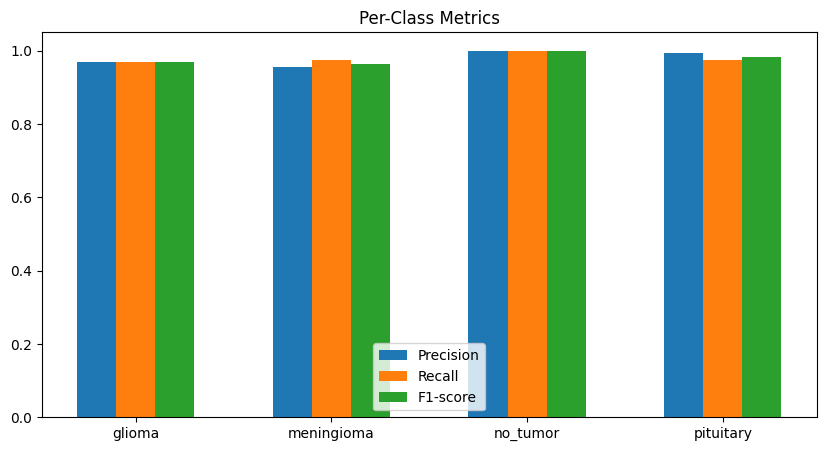

In [21]:
import matplotlib.pyplot as plt
import numpy as np # Added numpy import
import torch # Added torch import
from sklearn.metrics import classification_report

# Get predictions
y_true = []
y_pred = []

model.eval() # Set model to evaluation mode
with torch.no_grad(): # Disable gradient calculations for inference
    for images, masks, labels in test_loader: # Iterate over the test_loader
        images = images.to(device)
        # masks = masks.to(device) # Masks are not directly used for classification prediction here
        labels = labels.to(device)

        # Get model outputs (classification logits and segmentation logits)
        cls_logits, _ = model(images)

        # Get predicted class indices from classification logits
        preds = torch.argmax(cls_logits, dim=1).cpu().numpy()

        y_true.extend(labels.cpu().numpy()) # Collect true labels
        y_pred.extend(preds) # Collect predicted labels

report = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)

precision = [report[c]['precision'] for c in CLASS_NAMES]
recall = [report[c]['recall'] for c in CLASS_NAMES]
f1 = [report[c]['f1-score'] for c in CLASS_NAMES]

x = np.arange(len(CLASS_NAMES))

plt.figure(figsize=(10,5))
plt.bar(x - 0.2, precision, width=0.2, label='Precision')
plt.bar(x, recall, width=0.2, label='Recall')
plt.bar(x + 0.2, f1, width=0.2, label='F1-score')

plt.xticks(x, CLASS_NAMES)
plt.title("Per-Class Metrics")
plt.legend()
plt.show()

In [22]:
final_model_path = "corrected_brain_multitask_final.pth"
torch.save({
    "model_state_dict": model.state_dict(),
    "class_names": CLASS_NAMES,
    "img_size": IMG_SIZE,
    "history": history,
}, final_model_path)
print("Saved:", final_model_path)


Saved: corrected_brain_multitask_final.pth
